# Experiment 8
## Kalman Filtering using Python

**Name:** Ayush Gupta  
**SAP ID:** 500125537  
**Batch:** B7  
**Course:** Algorithms for Intelligent Systems and Robotics Lab

### Aim
To implement the Kalman filter in python, first for a single variable and then in the matrix form for tracking a robot moving in two dimensions, to compare its output with the raw sensor readings, and to study the effect of the noise parameters and of a sensor failure.

### Theory

Every real sensor is noisy and every model of motion is only approximate. The **Kalman filter** combines these two imperfect sources of information and produces an estimate which is better than either of them alone. It is the optimal estimator when the system is linear and the noise is Gaussian.

The filter keeps two things, the **state** $x$ which is what we want to know, and the **covariance** $P$ which is how unsure the filter is about that state. It runs in a cycle of two steps.

**Prediction**, using the motion model

$$\hat{x}_k = F x_{k-1} \qquad P_k = F P_{k-1} F^T + Q$$

The state is moved forward in time and the uncertainty grows, because a prediction is never perfect.

**Update**, using the measurement

$$K = P H^T (H P H^T + R)^{-1}$$
$$x = \hat{x} + K (z - H \hat{x}) \qquad P = (I - K H) P$$

The term $(z - H\hat{x})$ is the **innovation**, it is the difference between what the sensor reported and what the filter expected. $K$ is the **Kalman gain** and it decides how much of that difference to believe.

**The meaning of the matrices**
- $F$ : state transition matrix, how the state moves in one time step
- $H$ : measurement matrix, which parts of the state the sensor can actually see
- $Q$ : process noise, how wrong the motion model can be
- $R$ : measurement noise, how noisy the sensor is
- $P$ : the current uncertainty of the estimate
- $K$ : the gain, close to 1 means trust the sensor, close to 0 means trust the model

The important idea is that $K$ is not fixed by hand, it is computed at every step from $P$ and $R$. When the filter is unsure it listens to the sensor, and once it becomes confident it starts ignoring the sensor noise.

### 1. Part one : estimating a constant value
The simplest possible case. There is a fixed quantity, say the distance of a wall at 50 units, and a noisy sensor which reports it 100 times. Here the state is a single number so all the matrices become plain numbers.

Since the value does not move, F = 1, H = 1, and Q is kept very small because the model "nothing changes" is almost perfectly true.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

true_value = 50.0        # the real distance, unknown to the filter
R = 25.0                 # sensor noise variance, so std is 5
n = 100

measurements = true_value + np.random.normal(0, np.sqrt(R), n)

print("true value        :", true_value)
print("sensor noise std  :", np.sqrt(R))
print("first 5 readings  :", np.round(measurements[:5], 2))
print("worst reading     :", round(measurements[np.argmax(abs(measurements-true_value))], 2))

true value        : 50.0
sensor noise std  : 5.0
first 5 readings  : [52.48 49.31 53.24 57.62 48.83]
worst reading     : 36.9


In [2]:
def kalman_1d(measurements, R, Q=0.01, x0=0.0, P0=1000.0):
    x = x0          # first guess, deliberately bad
    P = P0          # and we say we are very unsure about it

    estimates, gains, covariances = [], [], []

    for z in measurements:
        # prediction, the value does not change so x stays, only the doubt grows
        P = P + Q

        # update
        K = P / (P + R)             # kalman gain
        x = x + K * (z - x)         # correct the estimate using the innovation
        P = (1 - K) * P             # and we are now more sure than before

        estimates.append(x)
        gains.append(K)
        covariances.append(P)

    return np.array(estimates), np.array(gains), np.array(covariances)


est, gain, cov = kalman_1d(measurements, R)

print("starting guess     :", 0.0)
print("final estimate     :", round(est[-1], 3), " (true value is", true_value, ")")
print("mean of all readings:", round(measurements.mean(), 3))

starting guess     : 0.0
final estimate     : 49.579  (true value is 50.0 )
mean of all readings: 49.481


In [3]:
rmse_raw = np.sqrt(np.mean((measurements - true_value)**2))
rmse_kf  = np.sqrt(np.mean((est - true_value)**2))

print("RMSE of the raw sensor :", round(rmse_raw, 3))
print("RMSE of the filter     :", round(rmse_kf, 3))
print("error reduced by       :", round((1 - rmse_kf/rmse_raw)*100, 1), "percent")

RMSE of the raw sensor : 4.548
RMSE of the filter     : 0.987
error reduced by       : 78.3 percent


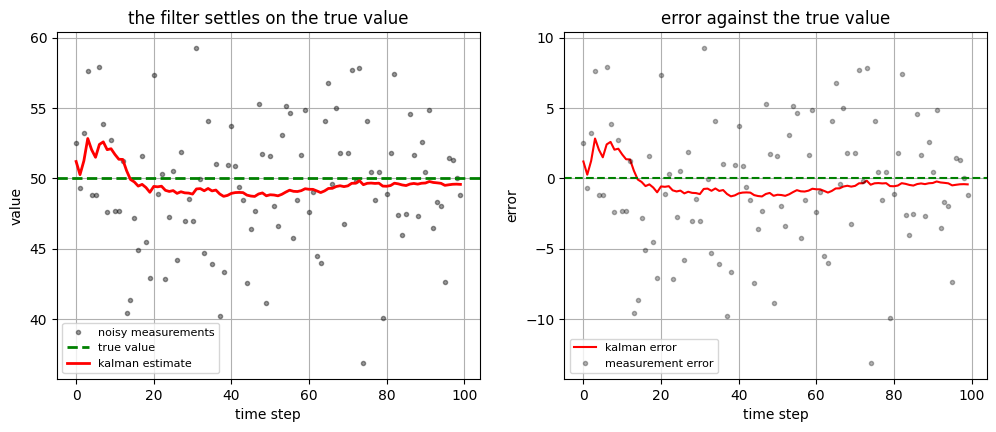

In [4]:
plt.figure(figsize=(12,4.5))

plt.subplot(1,2,1)
plt.plot(measurements, 'k.', alpha=0.4, label="noisy measurements")
plt.axhline(true_value, color='green', linestyle='--', linewidth=2, label="true value")
plt.plot(est, 'r', linewidth=2, label="kalman estimate")
plt.xlabel("time step"); plt.ylabel("value")
plt.title("the filter settles on the true value")
plt.legend(fontsize=8); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(est - true_value, 'r', label="kalman error")
plt.plot(measurements - true_value, 'k.', alpha=0.3, label="measurement error")
plt.axhline(0, color='green', linestyle='--')
plt.xlabel("time step"); plt.ylabel("error")
plt.title("error against the true value")
plt.legend(fontsize=8); plt.grid(True)

plt.show()

### 2. What the gain and the covariance are doing
This is the part which explains why the filter works. Both of them are plotted below.

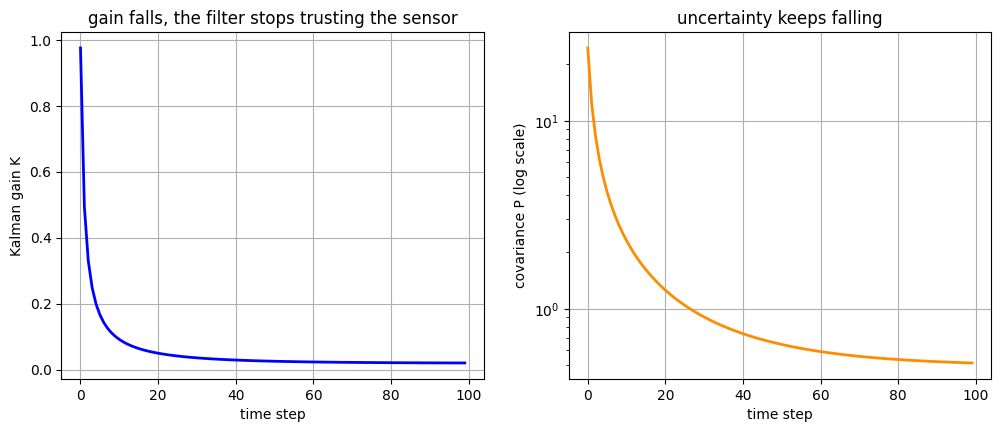

gain at step 1   : 0.9756
gain at step 100 : 0.0205

covariance at step 1   : 24.39
covariance at step 100 : 0.5137


In [5]:
plt.figure(figsize=(12,4.5))

plt.subplot(1,2,1)
plt.plot(gain, 'b', linewidth=2)
plt.xlabel("time step"); plt.ylabel("Kalman gain K")
plt.title("gain falls, the filter stops trusting the sensor")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(cov, 'darkorange', linewidth=2)
plt.yscale("log")
plt.xlabel("time step"); plt.ylabel("covariance P (log scale)")
plt.title("uncertainty keeps falling")
plt.grid(True)

plt.show()

print("gain at step 1   :", round(gain[0], 4))
print("gain at step 100 :", round(gain[-1], 4))
print()
print("covariance at step 1   :", round(cov[0], 3))
print("covariance at step 100 :", round(cov[-1], 4))

This is the whole behaviour of the filter in two pictures.

The gain starts at 0.9756, which means at the first step the filter throws away its own useless starting guess of 0 and takes almost the entire measurement. By the last step the gain has fallen to 0.0205, so a new reading now moves the estimate by only about two percent of its error. The filter has collected enough evidence and a single noisy reading can no longer disturb it.

The covariance shows the same thing from the other side. It starts at 1000, drops to 24.39 after the very first measurement, and reaches 0.5137 at the end. Since the gain is computed as P / (P + R), a falling P is what makes the gain fall, so the filter automatically becomes more stubborn as it becomes more certain, without anyone tuning it.

The final estimate is 49.579 against a true value of 50, and the error over the whole run dropped by 78.3 percent compared to the raw sensor.

### 3. Part two : tracking a robot moving in 2D
Now the real robotics case. A robot moves on a plane and a sensor, something like a GPS or an overhead camera, reports only its position and that too with noise. The velocity is never measured.

The state has four numbers

$$x = [\,p_x,\ v_x,\ p_y,\ v_y\,]^T$$

and with a time step dt the constant velocity model gives

$$F = \begin{bmatrix} 1 & dt & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & dt \\ 0 & 0 & 0 & 1 \end{bmatrix} \qquad H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \end{bmatrix}$$

H has only two rows because the sensor sees only $p_x$ and $p_y$. The interesting part is that the filter will still estimate the velocity, by noticing how the position keeps changing.

In [6]:
dt = 0.1
N = 200

F = np.array([[1, dt, 0,  0],
              [0,  1, 0,  0],
              [0,  0, 1, dt],
              [0,  0, 0,  1]], dtype=float)

H = np.array([[1, 0, 0, 0],
              [0, 0, 1, 0]], dtype=float)

print("F =\n", F)
print()
print("H =\n", H)
print()
print("the state is [px, vx, py, vy], the sensor gives only px and py")

F =
 [[1.  0.1 0.  0. ]
 [0.  1.  0.  0. ]
 [0.  0.  1.  0.1]
 [0.  0.  0.  1. ]]

H =
 [[1. 0. 0. 0.]
 [0. 0. 1. 0.]]

the state is [px, vx, py, vy], the sensor gives only px and py


In [7]:
np.random.seed(7)

r_noise = 2.0        # measurement noise variance
q_noise = 0.05       # process noise strength

# the true path of the robot, it drifts a little because the speed is not perfectly constant
true = np.zeros((N, 4))
true[0] = [0, 2.0, 0, 1.0]
for k in range(1, N):
    true[k] = F @ true[k-1]
    true[k, 1] += np.random.normal(0, 0.02)
    true[k, 3] += np.random.normal(0, 0.02)

measurements2d = true[:, [0, 2]] + np.random.normal(0, np.sqrt(r_noise), (N, 2))

print("time steps       :", N, " with dt =", dt)
print("starting position:", true[0, [0,2]], " starting velocity:", true[0, [1,3]])
print("final position   :", np.round(true[-1, [0,2]], 2))

time steps       : 200  with dt = 0.1
starting position: [0. 0.]  starting velocity: [2. 1.]
final position   : [39.49 17.69]


In [8]:
def kalman_2d(measurements, F, H, q, r, skip_range=None):
    # process noise for a constant velocity model
    Q = q * np.array([[dt**4/4, dt**3/2, 0,       0      ],
                      [dt**3/2, dt**2,   0,       0      ],
                      [0,       0,       dt**4/4, dt**3/2],
                      [0,       0,       dt**3/2, dt**2  ]])
    R = r * np.eye(2)

    x = np.zeros(4)             # the filter starts knowing nothing
    P = np.eye(4) * 500.0       # and being very unsure

    estimates = np.zeros((len(measurements), 4))
    p_trace = []

    for k in range(len(measurements)):
        # ---- prediction ----
        x = F @ x
        P = F @ P @ F.T + Q

        # ---- update, only if a measurement is available ----
        if skip_range is None or not (skip_range[0] <= k < skip_range[1]):
            innovation = measurements[k] - H @ x
            S = H @ P @ H.T + R
            K = P @ H.T @ np.linalg.inv(S)
            x = x + K @ innovation
            P = (np.eye(4) - K @ H) @ P

        estimates[k] = x
        p_trace.append(np.trace(P))

    return estimates, np.array(p_trace)


est2d, p_trace = kalman_2d(measurements2d, F, H, q_noise, r_noise)
print("filter finished, estimated state at the last step :")
print("   position :", np.round(est2d[-1, [0,2]], 3), "  true :", np.round(true[-1, [0,2]], 3))
print("   velocity :", np.round(est2d[-1, [1,3]], 3), "  true :", np.round(true[-1, [1,3]], 3))

filter finished, estimated state at the last step :
   position : [39.392 17.763]   true : [39.494 17.686]
   velocity : [1.886 0.882]   true : [1.824 0.723]


The velocity numbers above are the important ones. The sensor never measured velocity even once, the filter worked it out only from the way the position was changing.

In [9]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

# a simple moving average for comparison
window = 5
ma = np.vstack([np.convolve(measurements2d[:, i], np.ones(window)/window, mode='same')
                for i in range(2)]).T

rmse_meas = rmse(measurements2d, true[:, [0,2]])
rmse_ma   = rmse(ma[window:-window], true[window:-window][:, [0,2]])
rmse_kf2  = rmse(est2d[:, [0,2]], true[:, [0,2]])

print("RMSE of the raw measurements   :", round(rmse_meas, 4))
print("RMSE of a moving average (5)   :", round(rmse_ma, 4))
print("RMSE of the kalman filter      :", round(rmse_kf2, 4))
print()
print("improvement of the filter over the raw sensor :", round((1-rmse_kf2/rmse_meas)*100, 1), "percent")

RMSE of the raw measurements   : 1.3637
RMSE of a moving average (5)   : 0.625
RMSE of the kalman filter      : 0.4908

improvement of the filter over the raw sensor : 64.0 percent


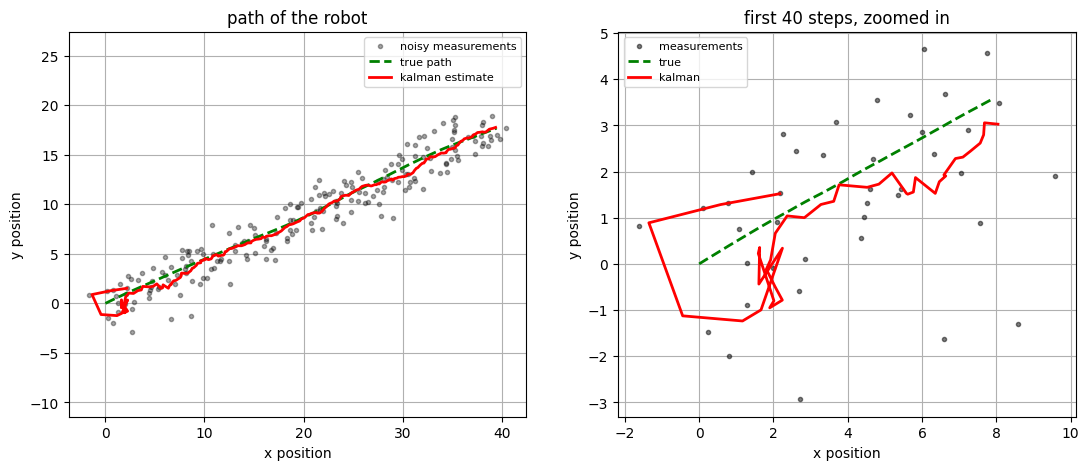

In [10]:
plt.figure(figsize=(13,5))

plt.subplot(1,2,1)
plt.plot(measurements2d[:,0], measurements2d[:,1], 'k.', alpha=0.35, label="noisy measurements")
plt.plot(true[:,0], true[:,2], 'g--', linewidth=2, label="true path")
plt.plot(est2d[:,0], est2d[:,2], 'r', linewidth=2, label="kalman estimate")
plt.xlabel("x position"); plt.ylabel("y position")
plt.title("path of the robot")
plt.legend(fontsize=8); plt.grid(True); plt.axis('equal')

plt.subplot(1,2,2)
plt.plot(measurements2d[:40,0], measurements2d[:40,1], 'k.', alpha=0.5, label="measurements")
plt.plot(true[:40,0], true[:40,2], 'g--', linewidth=2, label="true")
plt.plot(est2d[:40,0], est2d[:40,2], 'r', linewidth=2, label="kalman")
plt.xlabel("x position"); plt.ylabel("y position")
plt.title("first 40 steps, zoomed in")
plt.legend(fontsize=8); plt.grid(True)

plt.show()

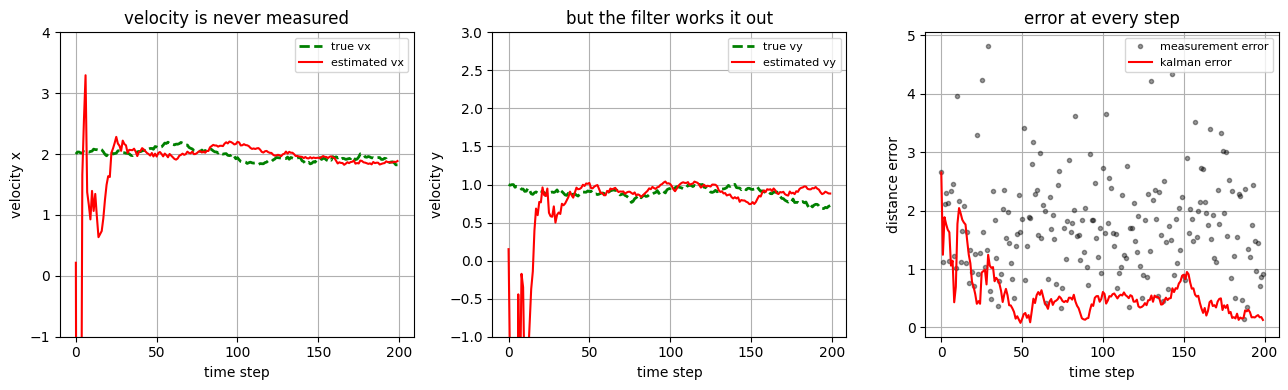

the transient at the start
   worst vx estimate : -15.73 at step 2
   worst vy estimate : -10.09 at step 3
   both are far outside the plotted range, that is why the axis is cut

velocity at step 50 : [1.96  1.021]  true : [2.118 0.907]
it takes about 22 steps for vx to come within 0.3 of the true value


In [11]:
plt.figure(figsize=(13,4))

plt.subplot(1,3,1)
plt.plot(true[:,1], 'g--', linewidth=2, label="true vx")
plt.plot(est2d[:,1], 'r', label="estimated vx")
plt.ylim(-1, 4)                      # the first few steps go far outside this, see the note below
plt.xlabel("time step"); plt.ylabel("velocity x")
plt.title("velocity is never measured")
plt.legend(fontsize=8); plt.grid(True)

plt.subplot(1,3,2)
plt.plot(true[:,3], 'g--', linewidth=2, label="true vy")
plt.plot(est2d[:,3], 'r', label="estimated vy")
plt.ylim(-1, 3)
plt.xlabel("time step"); plt.ylabel("velocity y")
plt.title("but the filter works it out")
plt.legend(fontsize=8); plt.grid(True)

plt.subplot(1,3,3)
err_meas = np.linalg.norm(measurements2d - true[:, [0,2]], axis=1)
err_kf = np.linalg.norm(est2d[:, [0,2]] - true[:, [0,2]], axis=1)
plt.plot(err_meas, 'k.', alpha=0.4, label="measurement error")
plt.plot(err_kf, 'r', linewidth=1.5, label="kalman error")
plt.xlabel("time step"); plt.ylabel("distance error")
plt.title("error at every step")
plt.legend(fontsize=8); plt.grid(True)

plt.tight_layout()
plt.show()

worst_vx = est2d[:, 1].argmin()
worst_vy = est2d[:, 3].argmin()
settled = int(np.argmax(np.abs(est2d[:, 1] - true[:, 1]) < 0.3))

print("the transient at the start")
print("   worst vx estimate :", round(est2d[worst_vx, 1], 2), "at step", worst_vx)
print("   worst vy estimate :", round(est2d[worst_vy, 3], 2), "at step", worst_vy)
print("   both are far outside the plotted range, that is why the axis is cut")
print()
print("velocity at step 50 :", np.round(est2d[50, [1,3]], 3), " true :", np.round(true[50, [1,3]], 3))
print("it takes about", settled, "steps for vx to come within 0.3 of the true value")

The y axis of the first two plots is deliberately cut to a small range. The filter starts with a velocity of zero and a covariance of 500, so the first few updates swing the velocity estimate wildly, down to about -15.7 at step 2 for vx and -10.1 at step 3 for vy. Those points are far outside the visible range on purpose, if the axis were left free the entire interesting part of the curve would be squeezed into a thin strip at the top.

The printed values below show how fast it recovers. The estimate comes within 0.3 of the true velocity after about 22 steps, which is roughly two seconds at dt = 0.1, and after that it tracks the true velocity closely even though velocity is never measured.

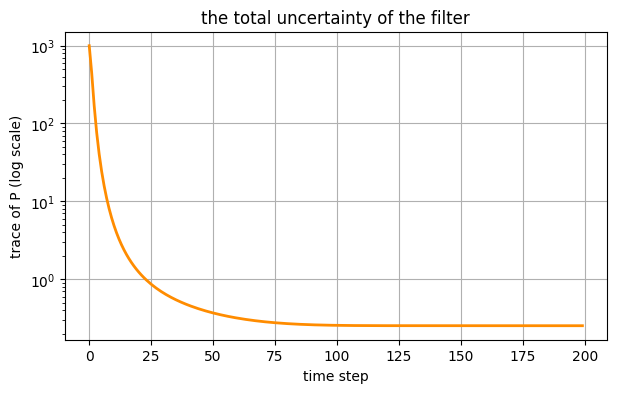

trace of P at the start : 994.12
trace of P at the end   : 0.2538

the filter needed about 23 steps to become confident


In [12]:
plt.figure(figsize=(7,4))
plt.plot(p_trace, 'darkorange', linewidth=2)
plt.yscale("log")
plt.xlabel("time step"); plt.ylabel("trace of P (log scale)")
plt.title("the total uncertainty of the filter")
plt.grid(True)
plt.show()

print("trace of P at the start :", round(p_trace[0], 2))
print("trace of P at the end   :", round(p_trace[-1], 4))
print()
print("the filter needed about", int(np.argmax(p_trace < 1.0)), "steps to become confident")

### 4. How sure is the filter, drawn on the map
The covariance P is not just a number used inside the equations, it can be drawn. The 2x2 block of P belonging to the position gives an ellipse around the estimate, and the true position should lie inside it about 95 percent of the time if the filter is working correctly.

A second function is written which returns the covariance and the innovation at every step, since the earlier one returned only the trace.

In [13]:
from matplotlib.patches import Ellipse

def kalman_2d_detailed(measurements, q, r):
    Q = q * np.array([[dt**4/4, dt**3/2, 0,       0      ],
                      [dt**3/2, dt**2,   0,       0      ],
                      [0,       0,       dt**4/4, dt**3/2],
                      [0,       0,       dt**3/2, dt**2  ]])
    R = r * np.eye(2)

    x = np.zeros(4)
    P = np.eye(4) * 500.0

    est = np.zeros((len(measurements), 4))
    pos_cov = []                                  # the 2x2 position part of P
    innov = np.zeros((len(measurements), 2))      # measurement minus prediction
    innov_sigma = np.zeros((len(measurements), 2))

    for k in range(len(measurements)):
        x = F @ x
        P = F @ P @ F.T + Q

        y = measurements[k] - H @ x
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        x = x + K @ y
        P = (np.eye(4) - K @ H) @ P

        est[k] = x
        pos_cov.append(P[np.ix_([0,2], [0,2])].copy())
        innov[k] = y
        innov_sigma[k] = [np.sqrt(S[0,0]), np.sqrt(S[1,1])]

    return est, pos_cov, innov, innov_sigma


est_d, pos_cov, innov, innov_sigma = kalman_2d_detailed(measurements2d, q_noise, r_noise)

for k in [0, 2, 5, 20, 100, 199]:
    ev = np.linalg.eigvalsh(pos_cov[k])
    print("step", str(k).rjust(3), ": 2 sigma ellipse semi axes =",
          round(2*np.sqrt(ev[1]), 3), "x", round(2*np.sqrt(ev[0]), 3))

step   0 : 2 sigma ellipse semi axes = 2.823 x 2.823
step   2 : 2 sigma ellipse semi axes = 2.448 x 2.448
step   5 : 2 sigma ellipse semi axes = 2.031 x 2.031
step  20 : 2 sigma ellipse semi axes = 1.192 x 1.192
step 100 : 2 sigma ellipse semi axes = 0.665 x 0.665
step 199 : 2 sigma ellipse semi axes = 0.661 x 0.661


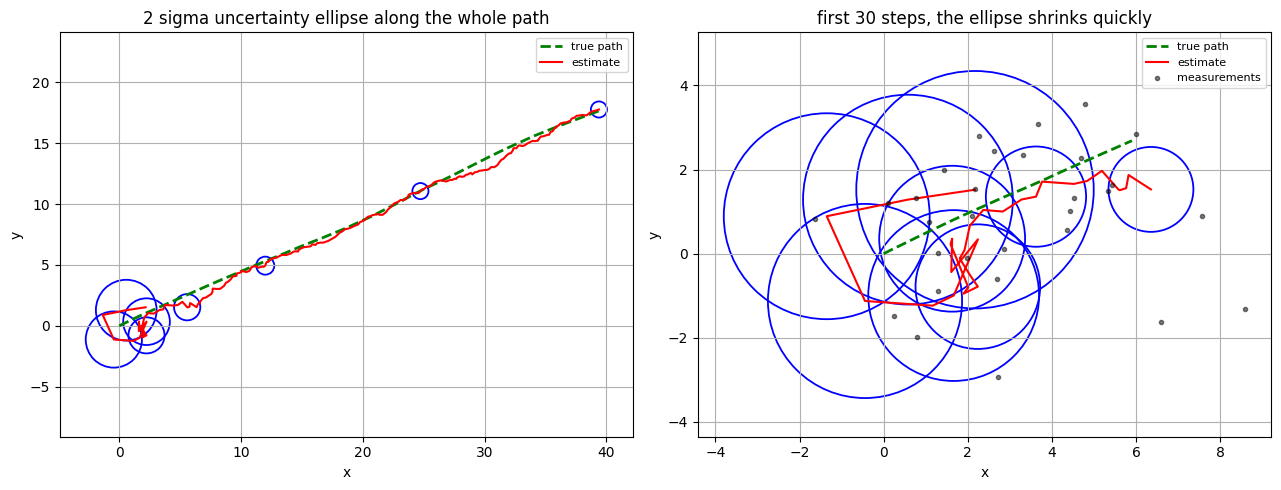

In [14]:
def draw_ellipses(ax, est, covs, steps, colour='blue'):
    for k in steps:
        ev, evec = np.linalg.eigh(covs[k])
        angle = np.degrees(np.arctan2(evec[1, -1], evec[0, -1]))
        # 2 sigma, so the width is 2 times 2 times the square root of the eigenvalue
        e = Ellipse((est[k,0], est[k,2]), 2*2*np.sqrt(ev[1]), 2*2*np.sqrt(ev[0]),
                    angle=angle, facecolor='none', edgecolor=colour, linewidth=1.3)
        ax.add_patch(e)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

ax = axes[0]
ax.plot(true[:,0], true[:,2], 'g--', linewidth=2, label="true path")
ax.plot(est_d[:,0], est_d[:,2], 'r', linewidth=1.5, label="estimate")
draw_ellipses(ax, est_d, pos_cov, [1, 3, 6, 12, 25, 60, 120, 199])
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("2 sigma uncertainty ellipse along the whole path")
ax.legend(fontsize=8); ax.grid(True); ax.axis('equal')

ax = axes[1]
ax.plot(true[:30,0], true[:30,2], 'g--', linewidth=2, label="true path")
ax.plot(est_d[:30,0], est_d[:30,2], 'r', linewidth=1.5, label="estimate")
ax.plot(measurements2d[:30,0], measurements2d[:30,1], 'k.', alpha=0.5, label="measurements")
draw_ellipses(ax, est_d, pos_cov, [0, 1, 2, 3, 5, 8, 12, 20, 29])
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("first 30 steps, the ellipse shrinks quickly")
ax.legend(fontsize=8); ax.grid(True); ax.axis('equal')

plt.tight_layout()
plt.show()

The ellipse is very large in the beginning because the filter was started with a covariance of 500, and it shrinks fast as measurements come in, from a semi axis of 2.823 at the first step to 0.661 at the end. After about twenty steps it stops shrinking and settles at a steady size, which is the point where the information gained from a new measurement exactly balances the uncertainty added by the prediction step.

The ellipses come out as circles here because x and y have the same noise and the same motion model, so there is no direction in which the filter is more confident. If the sensor were more accurate in one axis the ellipses would be stretched.

### 5. Checking whether the filter is actually consistent
There is a standard way to check a Kalman filter without knowing the true path, which is important because in a real robot the true path is never available. The **innovation**, that is measurement minus prediction, should behave like white noise with mean zero, and about 95 percent of it should lie inside the two sigma band which the filter itself predicts through S.

If the innovation drifts away from zero or leaves the band too often, the filter is inconsistent, usually meaning Q or R has been set wrong.

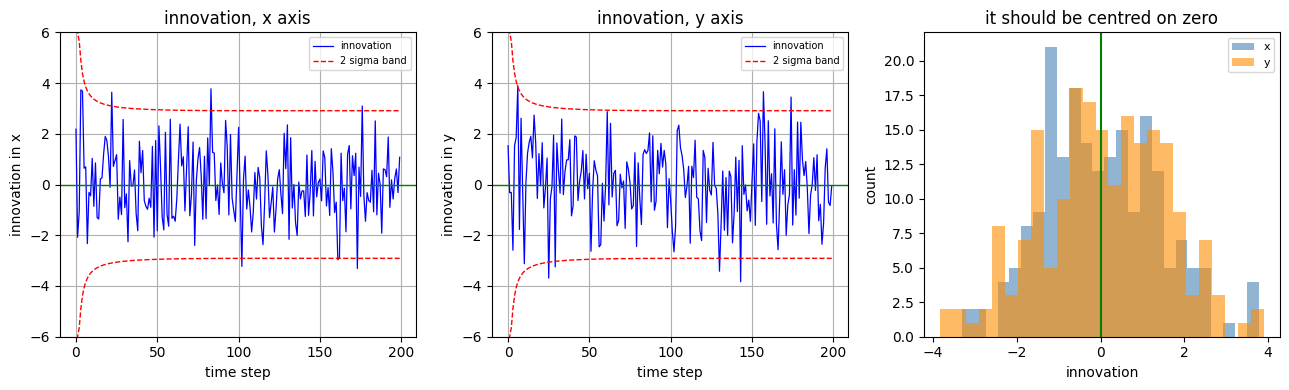

mean of the innovation      : [0.0163 0.0781]  (should be near zero)
std of the innovation       : [1.392 1.5  ]
std predicted by the filter : [1.4545 1.4545]

innovations inside the 2 sigma band : 96.8 percent  (theory says about 95)


In [15]:
plt.figure(figsize=(13,4))

for i, axis_name in enumerate(["x", "y"]):
    plt.subplot(1, 3, i+1)
    plt.plot(innov[:, i], 'b', linewidth=0.9, label="innovation")
    plt.plot(2*innov_sigma[:, i], 'r--', linewidth=1, label="2 sigma band")
    plt.plot(-2*innov_sigma[:, i], 'r--', linewidth=1)
    plt.axhline(0, color='green', linewidth=1)
    plt.ylim(-6, 6)
    plt.xlabel("time step"); plt.ylabel("innovation in " + axis_name)
    plt.title("innovation, " + axis_name + " axis")
    plt.legend(fontsize=7); plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(innov[:, 0], bins=25, alpha=0.6, label="x", color='steelblue')
plt.hist(innov[:, 1], bins=25, alpha=0.6, label="y", color='darkorange')
plt.axvline(0, color='green', linewidth=1.5)
plt.xlabel("innovation"); plt.ylabel("count")
plt.title("it should be centred on zero")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

inside = np.mean(np.abs(innov) < 2*innov_sigma) * 100
print("mean of the innovation      :", np.round(innov.mean(axis=0), 4), " (should be near zero)")
print("std of the innovation       :", np.round(innov.std(axis=0), 4))
print("std predicted by the filter :", np.round(innov_sigma[-1], 4))
print()
print("innovations inside the 2 sigma band :", round(inside, 1), "percent  (theory says about 95)")

The filter passes this test. The innovation stays scattered around zero with a mean of 0.0163 in x and 0.0781 in y, it looks like noise and not like a drifting curve, and its histogram is centred on zero.

The measured standard deviation of the innovation is 1.392 and 1.500, while the value predicted by the filter from S is 1.4545, so the filter's own estimate of how wrong it expects to be is correct. 96.8 percent of the innovations fall inside the two sigma band against the 95 percent expected from theory.

The two sigma band itself is wide at the beginning and narrows in the first twenty steps, for the same reason the ellipse shrank, the filter starts unsure so a large innovation is acceptable, and once it is confident it expects the measurements to agree with its prediction closely.

### 6. Tuning Q and R
Q and R are the two numbers which have to be chosen by the engineer. Their **ratio** is what actually matters, because it decides whether the filter believes the model or the sensor. Five settings are tried on the same data.

In [16]:
settings = [
    ["balanced, the correct one",   0.05,   2.0],
    ["R very large, trusts model",  0.05,  50.0],
    ["R very small, trusts sensor", 0.05,   0.05],
    ["Q very large",                5.0,    2.0],
    ["Q very small",                1e-6,   2.0],
]

tuning_results = []
for label, q, r in settings:
    e, _ = kalman_2d(measurements2d, F, H, q, r)
    err = rmse(e[:, [0,2]], true[:, [0,2]])
    tuning_results.append([label, q, r, err, e])
    print(label.ljust(30), "q =", str(q).ljust(7), "r =", str(r).ljust(6), "RMSE =", round(err, 4))

balanced, the correct one      q = 0.05    r = 2.0    RMSE = 0.4908
R very large, trusts model     q = 0.05    r = 50.0   RMSE = 0.463
R very small, trusts sensor    q = 0.05    r = 0.05   RMSE = 0.5653
Q very large                   q = 5.0     r = 2.0    RMSE = 0.5873
Q very small                   q = 1e-06   r = 2.0    RMSE = 0.4968


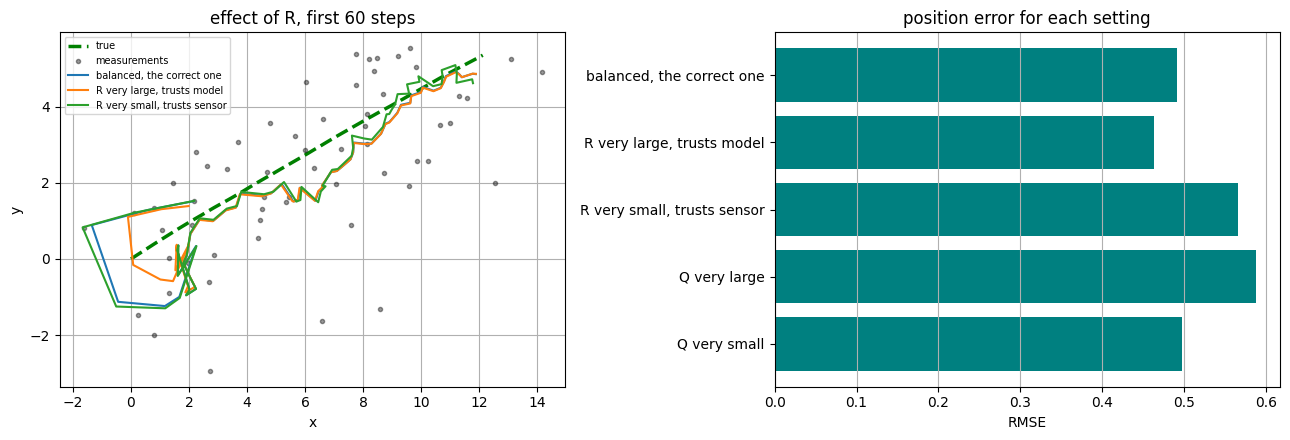

In [17]:
plt.figure(figsize=(13,4.5))

plt.subplot(1,2,1)
plt.plot(true[:60,0], true[:60,2], 'g--', linewidth=2.5, label="true")
plt.plot(measurements2d[:60,0], measurements2d[:60,1], 'k.', alpha=0.4, label="measurements")
for label, q, r, err, e in tuning_results[:3]:
    plt.plot(e[:60,0], e[:60,2], linewidth=1.5, label=label)
plt.xlabel("x"); plt.ylabel("y")
plt.title("effect of R, first 60 steps")
plt.legend(fontsize=7); plt.grid(True)

plt.subplot(1,2,2)
plt.barh([t[0] for t in tuning_results][::-1], [t[3] for t in tuning_results][::-1], color='teal')
plt.xlabel("RMSE"); plt.title("position error for each setting")
plt.grid(axis='x')

plt.tight_layout()
plt.show()

The balanced setting gives an RMSE of 0.4908, and two of the wrong settings behave exactly as the theory predicts.

When R is made very small, 0.05, the filter is being told that the sensor is nearly perfect, so it follows every noisy reading and the estimated path becomes jagged, and the error rises to 0.5653. When Q is made very large, 5.0, the filter is being told that its own model is useless, which has the same effect of leaning on the sensor, and the error becomes the worst at 0.5873.

One result here does not match the textbook expectation and it is worth stating honestly. Making R very large, 50.0, gave an RMSE of 0.4630 which is slightly **better** than the balanced setting. The reason is that in this simulation the robot really is moving in an almost perfectly straight line, so the constant velocity model is nearly exact, and a filter which trusts that model more than the sensor is right to do so. This is not a general result, it is a property of this particular path, and section 6 shows what happens to the same setting when the robot starts turning.

### 7. A harder case, a turning robot and a sensor failure
Until now the robot moved in a straight line, which is exactly what the constant velocity model assumes, so the filter had an easy job. Now two difficulties are added together.

First the robot **turns** between step 100 and step 200, so the motion model is now wrong. Second the sensor **fails completely** between step 150 and step 200, so during those 50 steps the filter receives nothing and has to run on prediction alone, which is what dead reckoning means.

In [18]:
N2 = 300
np.random.seed(7)

true_t = np.zeros((N2, 4))
true_t[0] = [0, 2.0, 0, 0.0]

for k in range(1, N2):
    vx, vy = true_t[k-1, 1], true_t[k-1, 3]
    if 100 <= k < 200:                       # the robot turns here
        ang = np.radians(1.2)
        vx, vy = vx*np.cos(ang) - vy*np.sin(ang), vx*np.sin(ang) + vy*np.cos(ang)
    true_t[k, 0] = true_t[k-1, 0] + vx*dt
    true_t[k, 2] = true_t[k-1, 2] + vy*dt
    true_t[k, 1], true_t[k, 3] = vx, vy

meas_t = true_t[:, [0,2]] + np.random.normal(0, np.sqrt(r_noise), (N2, 2))

est_ok, _   = kalman_2d(meas_t, F, H, q_noise, r_noise)
est_fail, _ = kalman_2d(meas_t, F, H, q_noise, r_noise, skip_range=(150, 200))

print("RMSE with the sensor working all the time :", round(rmse(est_ok[:, [0,2]], true_t[:, [0,2]]), 4))
print("RMSE when the sensor dies for 50 steps    :", round(rmse(est_fail[:, [0,2]], true_t[:, [0,2]]), 4))
print()
print("during the blackout (150 to 200)")
print("   error if the sensor was working :", round(rmse(est_ok[150:200][:, [0,2]], true_t[150:200][:, [0,2]]), 4))
print("   error running on prediction only:", round(rmse(est_fail[150:200][:, [0,2]], true_t[150:200][:, [0,2]]), 4))
print("   worst distance error at the end of the blackout :",
      round(np.linalg.norm(est_fail[199, [0,2]] - true_t[199, [0,2]]), 3))
print()
print("after the sensor comes back, error over the next 15 steps :",
      round(rmse(est_fail[200:215][:, [0,2]], true_t[200:215][:, [0,2]]), 4))

RMSE with the sensor working all the time : 0.9709
RMSE when the sensor dies for 50 steps    : 2.4172

during the blackout (150 to 200)
   error if the sensor was working : 1.7781
   error running on prediction only: 5.5383
   worst distance error at the end of the blackout : 13.307

after the sensor comes back, error over the next 15 steps : 2.8895


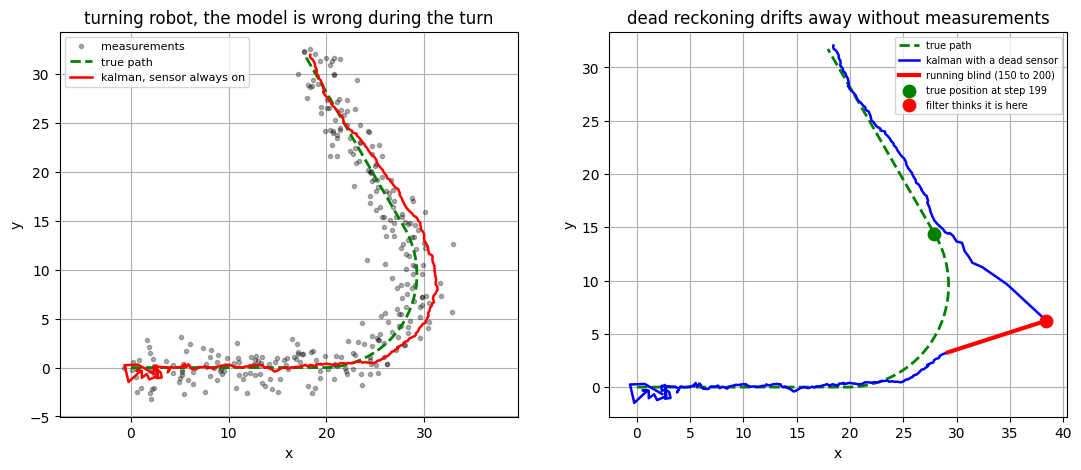

In [19]:
plt.figure(figsize=(13,5))

plt.subplot(1,2,1)
plt.plot(meas_t[:,0], meas_t[:,1], 'k.', alpha=0.3, label="measurements")
plt.plot(true_t[:,0], true_t[:,2], 'g--', linewidth=2, label="true path")
plt.plot(est_ok[:,0], est_ok[:,2], 'r', linewidth=1.8, label="kalman, sensor always on")
plt.xlabel("x"); plt.ylabel("y")
plt.title("turning robot, the model is wrong during the turn")
plt.legend(fontsize=8); plt.grid(True); plt.axis('equal')

plt.subplot(1,2,2)
plt.plot(true_t[:,0], true_t[:,2], 'g--', linewidth=2, label="true path")
plt.plot(est_fail[:,0], est_fail[:,2], 'b', linewidth=1.8, label="kalman with a dead sensor")
plt.plot(est_fail[150:200,0], est_fail[150:200,2], 'r', linewidth=3, label="running blind (150 to 200)")
plt.scatter([true_t[199,0]], [true_t[199,2]], c='green', s=80, zorder=5, label="true position at step 199")
plt.scatter([est_fail[199,0]], [est_fail[199,2]], c='red', s=80, zorder=5, label="filter thinks it is here")
plt.xlabel("x"); plt.ylabel("y")
plt.title("dead reckoning drifts away without measurements")
plt.legend(fontsize=7); plt.grid(True); plt.axis('equal')

plt.show()

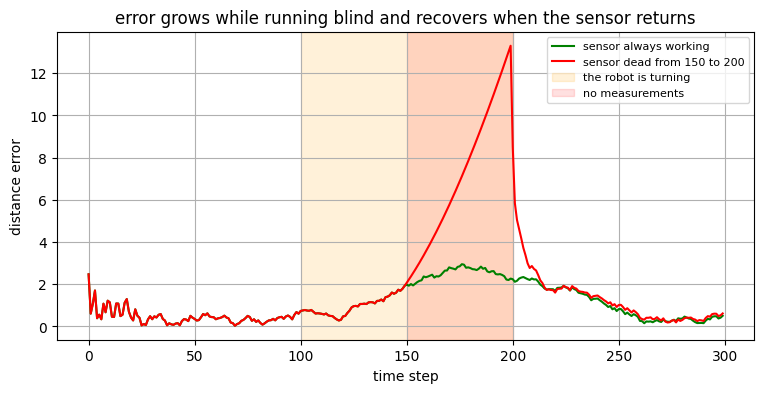

In [20]:
err_ok = np.linalg.norm(est_ok[:, [0,2]] - true_t[:, [0,2]], axis=1)
err_fail = np.linalg.norm(est_fail[:, [0,2]] - true_t[:, [0,2]], axis=1)

plt.figure(figsize=(9,4))
plt.plot(err_ok, 'g', label="sensor always working")
plt.plot(err_fail, 'r', label="sensor dead from 150 to 200")
plt.axvspan(100, 200, color='orange', alpha=0.15, label="the robot is turning")
plt.axvspan(150, 200, color='red', alpha=0.12, label="no measurements")
plt.xlabel("time step"); plt.ylabel("distance error")
plt.title("error grows while running blind and recovers when the sensor returns")
plt.legend(fontsize=8); plt.grid(True)
plt.show()

### 8. Going back to the tuning, now that the model is wrong
In section 4 the setting which trusted the model, R = 50, actually gave the lowest error. That happened only because the robot was moving in a perfectly straight line there, which is exactly what the constant velocity model assumes.

The same three settings are now run on the turning robot, where the model is no longer correct.

In [21]:
def kalman_simple(measurements, q, r):
    est, _ = kalman_2d(measurements, F, H, q, r)
    return est

print("turning robot, where the constant velocity model is wrong")
print()
print("setting".ljust(32), "overall RMSE".rjust(13), "RMSE during the turn".rjust(22))
print("-"*70)
for label, q, r in [["balanced", 0.05, 2.0],
                    ["R very large, trusts model", 0.05, 50.0],
                    ["Q larger, admits model error", 1.0, 2.0]]:
    e = kalman_simple(meas_t, q, r)
    overall = rmse(e[:, [0,2]], true_t[:, [0,2]])
    during  = rmse(e[100:200][:, [0,2]], true_t[100:200][:, [0,2]])
    print(label.ljust(32), str(round(overall,4)).rjust(13), str(round(during,4)).rjust(22))

turning robot, where the constant velocity model is wrong

setting                           overall RMSE   RMSE during the turn
----------------------------------------------------------------------
balanced                                0.9709                 1.3611
R very large, trusts model              3.1528                 2.7194
Q larger, admits model error             0.487                 0.5643


The result flips completely. The setting which was the best on the straight path, R = 50, is now the worst by a long way, its error jumps from 0.463 to 3.1528 because it keeps believing a model which has stopped being true. Increasing Q instead, which is the filter's way of admitting that the model is not reliable, brings the error down to 0.4870 and it becomes the best of the three.

So Q and R cannot be tuned once and forgotten. They encode an assumption about how much the motion model can be trusted, and that assumption has to match the way the robot actually moves.

### 9. Result

The Kalman filter was implemented in python for a scalar case and in the matrix form for two dimensional tracking.

**Part 1, estimating a constant value of 50 from a sensor with a noise std of 5**

| | Value |
|---|---|
| Starting guess | 0.0 |
| Final estimate | 49.579 |
| Kalman gain, first step to last | 0.9756 to 0.0205 |
| Covariance, first step to last | 24.39 to 0.5137 |
| RMSE of the raw sensor | 4.548 |
| RMSE of the filter | 0.987 |
| Error reduction | 78.3 percent |

**Part 2, tracking a robot in 2D where only the position is measured**

| Method | RMSE of the position |
|---|---|
| Raw measurements | 1.3637 |
| Moving average of 5 | 0.6250 |
| **Kalman filter** | **0.4908** |

Improvement of the filter over the raw sensor is 64.0 percent. The velocity, which was never measured, was estimated as (1.886, 0.882) against a true value of (1.824, 0.723). The trace of P fell from 994.12 to 0.2538 and the filter became confident after about 23 steps.

**Part 3, consistency check of the filter**

| | Value |
|---|---|
| Mean of the innovation | 0.0163 in x, 0.0781 in y |
| Std of the innovation, measured | 1.392 and 1.500 |
| Std predicted by the filter from S | 1.4545 |
| Innovations inside the 2 sigma band | 96.8 percent, theory says 95 |
| 2 sigma position ellipse, first step | 2.823 units |
| 2 sigma position ellipse, last step | 0.661 units |

**Part 4, tuning Q and R on the straight path**

| Setting | q | r | RMSE |
|---|---|---|---|
| Balanced | 0.05 | 2.0 | 0.4908 |
| R very large, trusts model | 0.05 | 50.0 | 0.4630 |
| R very small, trusts sensor | 0.05 | 0.05 | 0.5653 |
| Q very large | 5.0 | 2.0 | 0.5873 |
| Q very small | 1e-6 | 2.0 | 0.4968 |

**Part 5, a turning robot with a sensor failure between step 150 and 200**

| Situation | RMSE |
|---|---|
| Sensor working throughout | 0.9709 |
| Sensor dead for 50 steps | 2.4172 |
| During the blackout, with measurements | 1.7781 |
| During the blackout, prediction only | 5.5383 |
| Worst error at the end of the blackout | 13.307 units |
| First 15 steps after recovery | 2.8895 |

**Part 6, the same tuning settings on the turning robot**

| Setting | Overall RMSE | RMSE during the turn |
|---|---|---|
| Balanced | 0.9709 | 1.3611 |
| R very large, trusts model | 3.1528 | 2.7194 |
| Q larger, admits model error | 0.4870 | 0.5643 |

### 10. Conclusion

The Kalman filter was implemented from the basic equations, first for a single variable and then in the full matrix form for a robot moving in a plane, and its output was compared with the raw sensor readings and with a simple moving average.

The scalar case shows the mechanism of the filter very clearly. The Kalman gain fell from 0.9756 at the first step to 0.0205 at the last, and the covariance fell from 1000 to 0.5137. Since the gain is computed as P divided by P plus R, this happens on its own, the filter accepts almost the whole of the first measurement because it has nothing better, and becomes progressively harder to move as its own confidence grows. The error over the run was reduced by 78.3 percent compared to the raw sensor.

The two dimensional case shows why the filter is used in robotics rather than a simple smoothing method. Its RMSE of 0.4908 was better than both the raw measurements at 1.3637 and a five point moving average at 0.6250, but the more important result is that it estimated the velocity as (1.886, 0.882) against a true value of (1.824, 0.723) even though the sensor measured only position. A moving average can never do this, because it has no model of the system, it only smooths whatever it is given. The Kalman filter knows that position and velocity are connected through F, so an observation of one becomes information about the other.

The study of Q and R shows that these two values are not just noise settings, they are a statement about how much the motion model deserves to be trusted, and their ratio is what matters. On the straight path, trusting the model heavily with R = 50 gave the lowest error of 0.4630, better even than the correctly balanced filter. On the turning path the identical setting gave 3.1528, more than three times worse than the balanced filter, because the model it was trusting had stopped describing the robot. Raising Q instead, which is the filter's way of admitting that its model may be wrong, gave the best result of 0.4870 on that path. This is the most useful lesson of the experiment, a well tuned filter is tuned for a particular kind of motion.

The consistency check is worth recording separately because it can be done on a real robot where the true path is never known. The innovation stayed centred on zero, its measured spread of 1.392 and 1.500 matched the 1.4545 which the filter itself predicted through S, and 96.8 percent of the innovations fell inside the two sigma band against a theoretical 95 percent. Together with the covariance ellipse shrinking from 2.823 units to 0.661 and then holding steady, this shows the filter is not only accurate but also correctly aware of how accurate it is, which is what makes its output safe to use in a decision.

The sensor failure test shows the limit of the method. With no measurements for 50 steps the filter continued to produce an estimate by pure prediction, which is dead reckoning, and the error grew steadily to 13.307 units by the end of the blackout while the true robot had turned away. Once the measurements returned, the filter pulled back to the true path within about fifteen steps. This behaviour is exactly what is wanted in a real robot, it keeps working when a sensor drops out and it recovers when the sensor returns, but the estimate must not be trusted for a long blackout.

It is concluded that the Kalman filter is an efficient recursive estimator which needs only the previous state and the current measurement, without storing any history, which is why it is standard in robot navigation, sensor fusion and GPS with an inertial unit. Its accuracy depends on the linear model and the Gaussian noise assumptions holding, and where the motion is strongly non linear, an Extended or an Unscented Kalman filter is required instead.